In [2]:
# 기본 경로 설정
# ===============================================================
import os
import requests


ROOT_DIR = os.getcwd()
project_num = "13"


# 로컬 모드
if ROOT_DIR != "/content":
    IS_COLAB_MODE = False

    from dotenv import load_dotenv
    load_dotenv(dotenv_path=os.path.join(ROOT_DIR, ".env"))

    ROOT_DIR = "/".join(ROOT_DIR.split("/")[:-1])
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")


# 코랩 모드
else:
    IS_COLAB_MODE = True

    import subprocess
    from google.colab import drive, userdata

    drive.mount('/content/drive')

    # 압축 파일 확보
    if "raw.tar.gz" not in os.listdir():

        headers = {
            "Authorization": f"token {userdata.get('GITHUB_PAT')}",
            "Accept": "application/vnd.github.v3+json"
            }

        release_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/tags/data-v{project_num}"
        response = requests.get(release_url, headers=headers)

        asset_id = response.json().get('assets', [])[0]["id"]

        download_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/assets/{asset_id}"
        download_headers = headers.copy()
        download_headers["Accept"] = "application/octet-stream"

        with requests.get(download_url, headers=download_headers, stream=True) as r:
            r.raise_for_status()
            with open("raw.tar.gz", 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

    print("· 압축 파일 있음")

    # 압축 파일 및 경로 처리
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")
    DRIVE_DIR = os.path.join(ROOT_DIR, "drive", "MyDrive")
    SAVE_DIR = os.path.join(DRIVE_DIR, "runs", project_num)

    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)

    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=True)

    print("· 데이터 압축 해제 완료")

    if not os.path.exists(SAVE_DIR):
        os.mkdir(SAVE_DIR)

Mounted at /content/drive
· 압축 파일 있음
· 데이터 압축 해제 완료


In [3]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

In [6]:
from pathlib import Path

raw_json_path_list = [
    str(path) for path in Path(RAW_DIR).rglob("*.json")
    if not path.name.startswith(".")
    ]

len(raw_json_path_list)

2026

In [7]:
import random
import json

rand_idx = random.randint(1, len(raw_json_path_list))
rand_path = raw_json_path_list[rand_idx - 1]

with open(rand_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

rand_idx = random.randint(1, len(sample))
sample[rand_idx - 1]

{'Index': '3965',
 'RawText': '주문한 상품이 녹음이 안되는 불량 상품 와서 기분이 아주 별로네요. 고해상도라고 해서 기대했는데 그렇게 선명하지 않아 실망스럽네요',
 'Source': 'SNS',
 'Domain': 'IT기기',
 'MainCategory': '자동차기기',
 'ProductName': '특허받은 송가인 싹찍어 3채널 블랙박스 32G',
 'ReviewScore': '10',
 'Syllable': '72',
 'Word': '17',
 'RDate': '20210401',
 'GeneralPolarity': '-1',
 'Aspects': [{'Aspect': '품질',
   'SentimentText': '주문한 상품이 녹음이 안되는 불량 상품 와서 기분이 아주 별로네요. ',
   'SentimentWord': '10',
   'SentimentPolarity': '-1'},
  {'Aspect': '화질',
   'SentimentText': ' 고해상도라고 해서 기대했는데 그렇게 선명하지 않아 실망스럽네요',
   'SentimentWord': '7',
   'SentimentPolarity': '-1'}]}

In [8]:
import json
import pandas as pd

column_list = ["RawText", "Word", "GeneralPolarity"]
all_data = []

for path in raw_json_path_list:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)

        for item in dict_list:
            filtered_item = {key: item.get(key) for key in column_list}

            all_data.append(filtered_item)

filtered_df = pd.DataFrame(all_data, columns=column_list)

print(f"· 총 데이터: {len(filtered_df)}개")

· 총 데이터: 201616개


In [9]:
print("[결측치]")

for column in column_list:
    if sum(filtered_df[column].isna()) > 0:
        print(f"· 결측 항목: {column}")
        print(f"· {sum(filtered_df[column].isna())}개")
        print(f"· 예시: \n{filtered_df[filtered_df[column].isna()].head(5)}")

        filtered_df = filtered_df.dropna()
        print(f"\n· 제거 후 데이터: {len(filtered_df)}개")

filtered_df["GeneralPolarity"] = filtered_df["GeneralPolarity"].astype(int)

[결측치]
· 결측 항목: GeneralPolarity
· 17091개
· 예시: 
                                                RawText Word GeneralPolarity
50    광고를 보고 너무 깨끗하고 순수해 보이는 디자인 이미지가 마음에 들어서 구매해 본 ...   83            None
204   OO 오 드 퍼퓸 블랙베리 향 사용후기예요.  이거 물건이에요ㅎㅎ 정말 저렴하거든요...   69            None
508   아기낳은 후 피부가 칙칙해지는 게 아무리 가려도 마땅한 게 없네요.  잘 가려지는 ...  147            None
959   안녕하세요~ 오늘 소개 해드리고 싶은 제품은 ㅇㅇㅇ 바디워시입니다~ 바디워시 제품 ...   86            None
1195  저는 화장을 짙게 하는 편인데, 아이브로우는 짙게하면 좀 너무 눈썹만 눈에 띄더라고...   76            None

· 제거 후 데이터: 184525개


In [10]:
print("[중복치]")

if sum(filtered_df["RawText"].duplicated()) > 0:
    print(filtered_df[filtered_df["RawText"].duplicated()].head(5))

else:
    print("중복치 없음")

[중복치]
중복치 없음


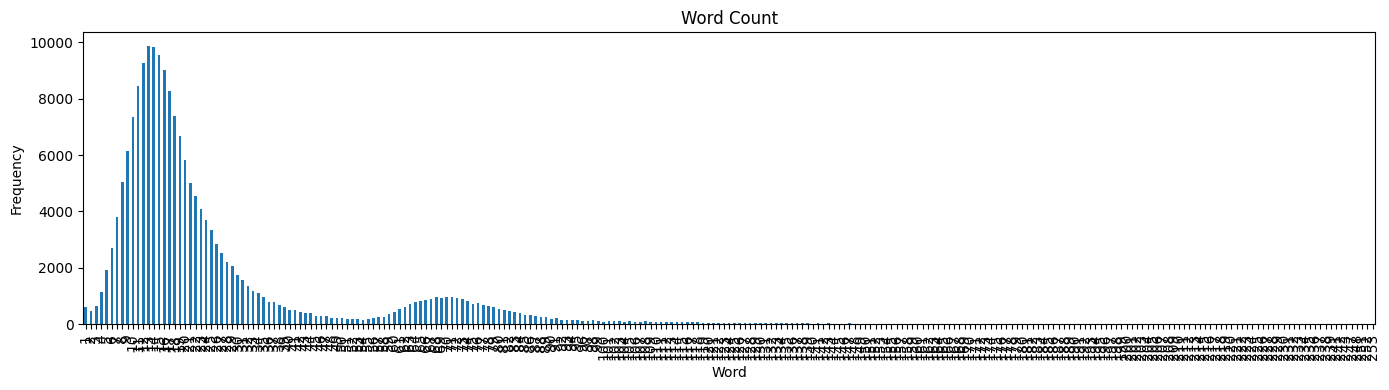

In [11]:
filtered_df["Word"] = filtered_df["Word"].astype(int)

data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

In [12]:
print("[극단치]")

filtered_df = filtered_df[filtered_df["Word"] <= 50]

print(f"· 제거 후 데이터: {len(filtered_df)}개")

[극단치]
· 제거 후 데이터: 158825개


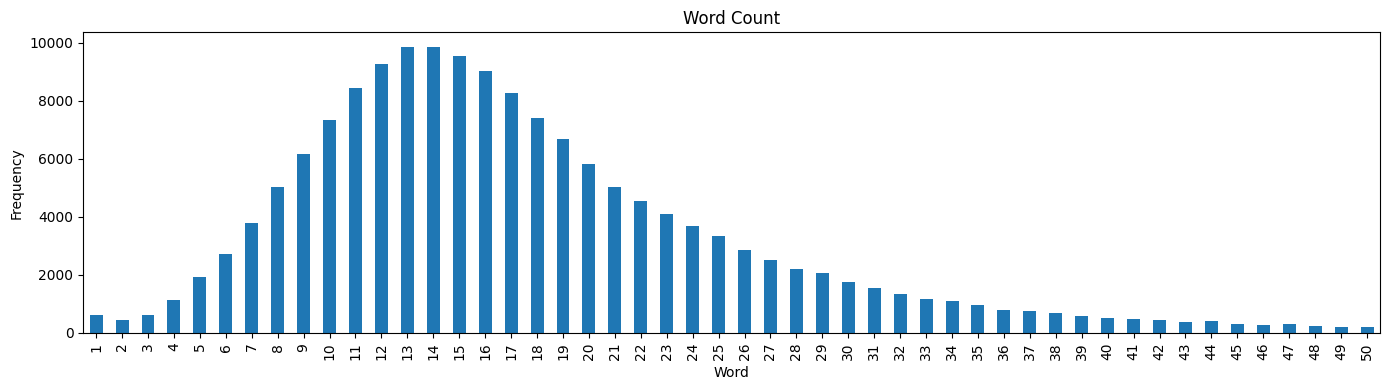

In [13]:
data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

filtered_df = filtered_df.drop("Word", axis=1)

In [14]:
filtered_df = filtered_df.reset_index().drop("index", axis=1)

filtered_df["GeneralPolarity"] += 1

filtered_df["GeneralPolarity"].value_counts()

,count
GeneralPolarity,
2,100348
1,33299
0,25178


---

In [15]:
RAW_TEXT_LIST = list(filtered_df["RawText"])
CLASS_LIST = list(filtered_df["GeneralPolarity"])

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "tabularisai/multilingual-sentiment-analysis"
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
    )
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [17]:
from torch.utils.data import Dataset

class BasicDataset(Dataset):
    def __init__(self, tokenizer):
        self.X_list = RAW_TEXT_LIST
        self.y_list = CLASS_LIST
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, index):
        text = self.X_list[index]

        X = self.tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        y = self.y_list[index]

        return {
            "input_ids": X["input_ids"],
            "attention_mask": X["attention_mask"],
            "label": y
            }

SIMPLE_DATASET = BasicDataset(tokenizer=tokenizer)

In [18]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

train_indices, tmp_indices = train_test_split(
    list(range(len(SIMPLE_DATASET))),
    test_size=0.2,
    stratify=CLASS_LIST
    )

val_indices, test_indices = train_test_split(
    list(range(len(tmp_indices))),
    test_size=0.5,
    stratify=[CLASS_LIST[idx] for idx in tmp_indices]
    )

simple_train_subset = Subset(SIMPLE_DATASET, train_indices)
simple_val_subset = Subset(SIMPLE_DATASET, val_indices)
simple_test_subset = Subset(SIMPLE_DATASET, test_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(SIMPLE_DATASET)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")
print(f"· 분할 후 테스트 데이터: {len(test_indices)}개 ({len(test_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 158825개
· 분할 후 학습 데이터: 127060개 (80.00%)
· 분할 후 검증 데이터: 15882개 (10.00%)
· 분할 후 테스트 데이터: 15883개 (10.00%)


In [19]:
# 샘플러 설정
labels = torch.tensor([CLASS_LIST[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = len(train_indices) / class_counts.float()
samples_weights = class_weights[labels]

simple_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
    )

print(f"[학습 데이터]")
print(f"· 부정 리뷰: {class_counts[0]}개 ({class_counts[0] / len(labels) * 100:.2f}%)")
print(f"· 중립 리뷰: {class_counts[1]}개 ({class_counts[1] / len(labels) * 100:.2f}%)")
print(f"· 긍정 리뷰: {class_counts[2]}개 ({class_counts[2] / len(labels) * 100:.2f}%)")

print(f"\n[샘플러 가중치]")
print(f"· 부정 클래스: {class_weights[0]:.4f}")
print(f"· 중립 클래스: {class_weights[1]:.4f}")
print(f"· 긍정 클래스: {class_weights[2]:.4f}")

# 채널별 데이터 로더 설정
SIMPLE_TRAIN_LOADER = DataLoader(simple_train_subset, batch_size=64, sampler=simple_sampler, shuffle=False, num_workers=4)
SIMPLE_VAL_LOADER = DataLoader(simple_val_subset, batch_size=64, shuffle=False, num_workers=4)
SIMPLE_TEST_LOADER = DataLoader(simple_test_subset, batch_size=64, shuffle=False, num_workers=4)

[학습 데이터]
· 부정 리뷰: 20143개 (15.85%)
· 중립 리뷰: 26639개 (20.97%)
· 긍정 리뷰: 80278개 (63.18%)

[샘플러 가중치]
· 부정 클래스: 6.3079
· 중립 클래스: 4.7697
· 긍정 클래스: 1.5827


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [20]:
import torch.optim as optim

for param in model.parameters():
    param.requires_grad = True

model.to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

In [21]:
# 학습 유틸리티 설정

# wandb
if IS_COLAB_MODE:
    subprocess.run(["pip", "install", "wandb", "-qU"])

import wandb

if IS_COLAB_MODE:
    wandb.login(key=userdata.get("WANDB_API_KEY"))
else:
    wandb.login(key=os.getenv("WANDB_API_KEY"))



# 텔레그램
def send_telegram_message(message):
    if IS_COLAB_MODE:
        token = userdata.get("TELEGRAM_BOT_TOKEN")
        chat_id = userdata.get("TELEGRAM_CHAT_ID")

    else:
        token = os.getenv("TELEGRAM_BOT_TOKEN")
        chat_id = os.getenv("TELEGRAM_CHAT_ID")


    url = f'https://api.telegram.org/bot{token}/sendMessage'
    payload = {
        'chat_id': chat_id,
        'text': message
        }

    requests.post(url, json=payload)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wsi0720 (wsi0720-sungkyunkwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [22]:
class TrainerConfig:
    def __init__(self, mode, patience=3):
        self.mode = mode
        self.save_dir = os.path.join(SAVE_DIR, self.mode)
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def step(self, epoch, train_loss, val_loss, model, tokenizer):
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": self.best_loss
            })

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            model.save_pretrained(os.path.join(self.save_dir, "best_model"))
            tokenizer.save_pretrained(os.path.join(self.save_dir, "best_model"))

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        model.save_pretrained(os.path.join(self.save_dir, "last_model"))


simple_trainer_config = TrainerConfig(mode="simple", patience=5)

In [26]:
id_path = os.path.join(simple_trainer_config.save_dir, f"wandb_id_{simple_trainer_config.mode}.txt")

if not os.path.exists(simple_trainer_config.save_dir):

    os.mkdir(simple_trainer_config.save_dir)

    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"

else:
    if os.path.exists(id_path):
        with open(id_path, "r") as f:
            id = f.read().strip()
        resume = "must"

    else:
        id = wandb.util.generate_id()
        with open(id_path, "w") as f:
            f.write(id)
        resume = "allow"

wandb.init(
    project="13",
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={
        "model": model_name
        }
    )


resume_dir = os.path.join(simple_trainer_config.save_dir, "last_model")

if os.path.exists(resume_dir):
    model = AutoModelForSequenceClassification.from_pretrained(resume_dir)
    tokenizer = AutoTokenizer.from_pretrained(resume_dir)
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


checkpoint_path = os.path.join(resume_dir, "training_state.pt")

if not os.path.exists(checkpoint_path):
    start_epoch = 0
else:
    checkpoint = torch.load(checkpoint_path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1


In [ ]:
num_epochs = 3

for epoch in range(start_epoch, start_epoch + num_epochs):
    clean_cache()

    # 학습 모드
    model.train()
    total_train_loss = 0

    for batch in SIMPLE_TRAIN_LOADER:
        optimizer.zero_grad()

        batch = {key: value.to(DEVICE) for key, value in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(SIMPLE_TRAIN_LOADER)
    print(f"· Epoch {epoch+1} Train Loss: {average_train_loss:.4f}")


    # 평가 모드
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in SIMPLE_VAL_LOADER:
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            outputs = model(**batch)
            total_val_loss += outputs.loss.item()

    average_val_loss = total_val_loss / len(SIMPLE_VAL_LOADER)
    print(f"· Epoch {epoch+1} Val Loss: {average_val_loss:.4f}")

    simple_trainer_config.step(epoch, average_train_loss, average_val_loss, model, tokenizer)


    if simple_trainer_config.early_stop:
        send_telegram_message(f"{simple_trainer_config.mode} 얼리 스톱")
        print("Early Stopped")
        break

send_telegram_message(f"{simple_trainer_config.mode} 학습 완료")